In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
import pandas as pd
from lib.cux003 import FactorEvaluate1
from lib.attr001.ftd001 import *

/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:11: UserWarning: if use distributed calculating, please configure MQ_URL
  warnings.warn('if use distributed calculating, please configure MQ_URL')
/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:15: UserWarning: if use distributed calculating, please configure NTN_URL
  warnings.warn('if use distributed calculating, please configure NTN_URL')
/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:19: UserWarning: if use memory database, please configure KN_MG
  warnings.warn('if use memory database, please configure KN_MG')
/workspace/worker/env/lingua/lib/python3.8/site-packages/Finance_Jindowin-1.5.4-py3.8.egg/jdw/__init__.py:27: UserWarning: if use trader, please configure ATL_URL
  warnings.warn('if use trader, please configure ATL_URL')
/workspace/worker/env/lingua/lib

#### 监控环境

In [3]:
mongo_client = MongoDBManager(uri=os.environ['MG_URI'])

In [4]:
query = {'category':'research'}
cursor = mongo_client[os.environ['MG_COLL']]["realm_raw_factors"].find(query)
trade_factors_dt = pd.DataFrame(cursor)
trade_factors_dt = trade_factors_dt.drop(['_id'],axis=1)
trade_factors_dt.head()

,category,code,name,trade_time,value
0,trader,RB,"EMA(30,SIGMOID('iv012_2_3_1'))",2026-05-06 10:13:00,0.151689
1,trader,RB,"EMA(30,SIGMOID('iv012_2_3_1'))",2026-05-06 10:14:00,-0.001503
2,trader,RB,"EMA(30,SIGMOID('iv012_2_3_1'))",2026-05-06 10:15:00,-0.128637
3,trader,RB,"EMA(30,SIGMOID('iv012_2_3_1'))",2026-05-06 10:30:00,-0.332655
4,trader,RB,"EMA(30,SIGMOID('iv012_2_3_1'))",2026-05-06 10:31:00,-0.431763


In [5]:
trader_factors_wide = trade_factors_dt.pivot(index=['trade_time','code'], columns='name', values='value').reset_index()
trader_factors_wide['trade_time'] = pd.to_datetime(trader_factors_wide['trade_time'])
trader_factors_wide.columns.name = None
trader_factors_wide.head()

,trade_time,code,"EMA(30,SIGMOID('iv012_2_3_1'))","EMA(5,'tc004_1_1_2_0')","EMA(5,MDIFF(15,'tv007_1_2_1'))","MDEMA(120,'tc004_1_1_2_0')","WMA(10,'tv004_1_2_0')"
0,2026-05-06 10:13:00,RB,0.151689,-0.500574,-0.577901,-0.435508,-0.560071
1,2026-05-06 10:14:00,RB,-0.001503,-0.491822,-0.465924,-0.592760,-0.743936
2,2026-05-06 10:15:00,RB,-0.128637,-0.261694,-0.300786,-0.502821,-0.562884
3,2026-05-06 10:30:00,RB,-0.332655,-0.146598,-0.489366,-0.432079,-0.556206
4,2026-05-06 10:31:00,RB,-0.431763,-0.282109,-0.366955,-0.539066,-0.535678


In [6]:
query = {'category':'research'}
cursor = mongo_client[os.environ['MG_COLL']]["realm_raw_returns"].find(query)
trader_returns_dt = pd.DataFrame(cursor)
trader_returns_dt = trader_returns_dt.drop(['_id'],axis=1)
trader_returns_dt.rename(columns={'value':'nxt1_ret'},inplace=True)
trader_returns_dt = trader_returns_dt[['trade_time','code','nxt1_ret']]
trader_returns_dt['trade_time'] = pd.to_datetime(trader_returns_dt['trade_time'])
trader_returns_dt.head()

,trade_time,code,nxt1_ret
0,2026-05-06 10:13:00,RB,-0.000617
1,2026-05-06 10:14:00,RB,0.000924
2,2026-05-06 10:15:00,RB,0.000924
3,2026-05-06 10:30:00,RB,0.000616
4,2026-05-06 10:31:00,RB,0.001233


In [7]:
trader_normal_data = trader_factors_wide.merge(trader_returns_dt, on=['trade_time','code'])
trader_normal_data = trader_normal_data[trader_normal_data['trade_time'] < '2026-04-30']

In [8]:
trader_normal_data.head()

,trade_time,code,"EMA(30,SIGMOID('iv012_2_3_1'))","EMA(5,'tc004_1_1_2_0')","EMA(5,MDIFF(15,'tv007_1_2_1'))","MDEMA(120,'tc004_1_1_2_0')","WMA(10,'tv004_1_2_0')",nxt1_ret


In [9]:
### 读取投研环境数据
rearch_normal_data = pd.read_feather(
    "/workspace/worker/pj/Chrono/genuis/mizar/records/ricso2/rbb/temp/model/113001/5/final_pro_data.feather")

In [10]:
rearch_normal_data = rearch_normal_data[rearch_normal_data['trade_time'] >= '2026-01-01']
rearch_normal_data.head()

,trade_time,code,"WMA(30,'oi034_1_2_1')","WMA(30,'tc012_1_1_2_0')","MDEMA(120,'oi004_1_2_0')","EMA(10,'tc008_1_2_0')","MDEMA(120,'tc004_1_1_2_0')","WMA(10,'tv004_1_2_0')","MADiff(30,'tf022_1_2_1')","EMA(5,'tc004_1_1_2_0')",...,ASIN(SIGLOG2ABS('oi004_5_10_1')),"MDIFF(5,MDIFF(5,'oi004_5_10_1'))","SIGLOG2ABS(ASIN(MADecay(10,'oi039_2_3_1')))","SIGLOG2ABS(WMA(10,'oi039_2_3_1'))",ASIN('oi004_5_10_1'),"MDEMA(90,'oi004_1_2_1')","MDIFF(5,'oi004_5_10_1')","MDIFF(60,'iv012_2_3_1')","MA(10,'iv012_1_2_1')",nxt1_ret_5h
1104210,2026-01-05 09:00:00,RB,-0.884981,-0.941842,-0.187744,-1.000000,-1.000000,-1.000000,-0.418263,-1.000000,...,-0.586304,-0.586292,-0.396934,-0.396934,-0.586292,-0.688703,-0.586292,-0.899131,-0.340875,-0.000407
1104211,2026-01-05 09:01:00,RB,-0.899826,-0.823530,-0.196919,-0.651125,-0.670268,-1.000000,-0.933195,-0.473476,...,-0.749128,-0.749119,-0.636933,-0.636933,-0.749119,-0.886654,-0.749119,-0.745279,-0.458629,-0.000604
1104212,2026-01-05 09:02:00,RB,-0.910209,-0.875496,-1.000000,-0.661964,-0.667877,-0.785965,-0.984512,-0.426617,...,-0.850894,-0.850898,-0.817971,-0.817971,-0.850898,-0.942619,-0.850898,-0.636396,-0.670097,0.000097
1104213,2026-01-05 09:03:00,RB,-0.609452,-0.448002,-0.751035,-0.340508,-0.543755,-0.563170,-0.702835,-0.225200,...,-0.631536,-0.631537,-0.678503,-0.678503,-0.631537,-0.574851,-0.631537,-0.253059,-0.547368,0.000179
1104214,2026-01-05 09:04:00,RB,-0.417998,-0.301360,-0.605527,-0.038763,-0.274850,-0.342814,-0.473464,0.170033,...,-0.418406,-0.418402,-0.466487,-0.466487,-0.418402,-0.334134,-0.418402,0.002119,-0.380156,-0.000392


In [11]:
rearch_normal_data[['trade_time','code','nxt1_ret_5h']]

,trade_time,code,nxt1_ret_5h
1104210,2026-01-05 09:00:00,RB,-0.000407
1104211,2026-01-05 09:01:00,RB,-0.000604
1104212,2026-01-05 09:02:00,RB,0.000097
1104213,2026-01-05 09:03:00,RB,0.000179
1104214,2026-01-05 09:04:00,RB,-0.000392
...,...,...,...
1130554,2026-04-29 22:57:00,RB,0.000698
1130555,2026-04-29 22:58:00,RB,0.000673
1130556,2026-04-29 22:59:00,RB,0.000891
1130557,2026-04-29 23:00:00,RB,0.000425


In [13]:
name = "EMA(5,'tc004_1_1_2_0')"
evaluate1 = FactorEvaluate1(factor_data=trader_normal_data,
                                    factor_name=name,
                                    ret_name="nxt1_ret",
                                    roll_win=15, ## 已经标准化过
                                    fee=0,
                                    scale_method='raw',
                                    expression=name,
                                    resampling_win=5)

evaluate1.run()
evaluate1.plot_results()

# name = "EMA(5,'tc004_1_1_2_0')"
# evaluate2 = FactorEvaluate1(factor_data=rearch_normal_data,
#                                     factor_name=name,
#                                     ret_name="nxt1_ret_5h",
#                                     roll_win=15, ## 已经标准化过
#                                     fee=0,
#                                     scale_method='raw',
#                                     expression=name,
#                                     resampling_win=5)

# evaluate2.run()
# evaluate2.plot_results()

RuntimeError: Please run the 'run()' method before plotting.

In [13]:
trader_normal_data[['trade_time',name,'nxt1_ret']].head(10)

,trade_time,"EMA(5,'tc004_1_1_2_0')",nxt1_ret
0,2026-01-05 09:00:00,-1.000000,-7.415943e-17
1,2026-01-05 09:01:00,-0.447998,-9.589261e-04
2,2026-01-05 09:02:00,-0.436435,3.198465e-04
3,2026-01-05 09:03:00,-0.233086,3.199488e-04
4,2026-01-05 09:04:00,0.199970,-9.598465e-04
5,2026-01-05 09:05:00,0.374130,-6.400000e-04
6,2026-01-05 09:06:00,0.370727,-3.198465e-04
7,2026-01-05 09:07:00,-0.109807,-6.397953e-04
8,2026-01-05 09:08:00,-0.120178,2.519686e-16
9,2026-01-05 09:09:00,-0.019976,9.598465e-04


In [14]:
rearch_normal_data[['trade_time',name,'nxt1_ret_5h']].head(10)

,trade_time,"EMA(5,'tc004_1_1_2_0')",nxt1_ret_5h
1104210,2026-01-05 09:00:00,-1.000000,-0.000407
1104211,2026-01-05 09:01:00,-0.473476,-0.000604
1104212,2026-01-05 09:02:00,-0.426617,0.000097
1104213,2026-01-05 09:03:00,-0.225200,0.000179
1104214,2026-01-05 09:04:00,0.170033,-0.000392
1104215,2026-01-05 09:05:00,0.313870,-0.000261
1104216,2026-01-05 09:06:00,0.307690,-0.000925
1104217,2026-01-05 09:07:00,-0.098053,-0.000578
1104218,2026-01-05 09:08:00,-0.096385,-0.000542
1104219,2026-01-05 09:09:00,-0.010658,0.000923


In [13]:
tr_data =trader_normal_data[['trade_time',name]].merge(rearch_normal_data[['trade_time','nxt1_ret_5h']],
                                              on=['trade_time'])
tr_data.tail()

,trade_time,"EMA(5,'tc004_1_1_2_0')",nxt1_ret_5h
26222,2026-04-29 22:56:00,-0.079176,0.000294
26223,2026-04-29 22:57:00,-0.063321,0.000698
26224,2026-04-29 22:58:00,0.528800,0.000673
26225,2026-04-29 22:59:00,0.312029,0.000891
26226,2026-04-29 23:00:00,0.891057,0.000425


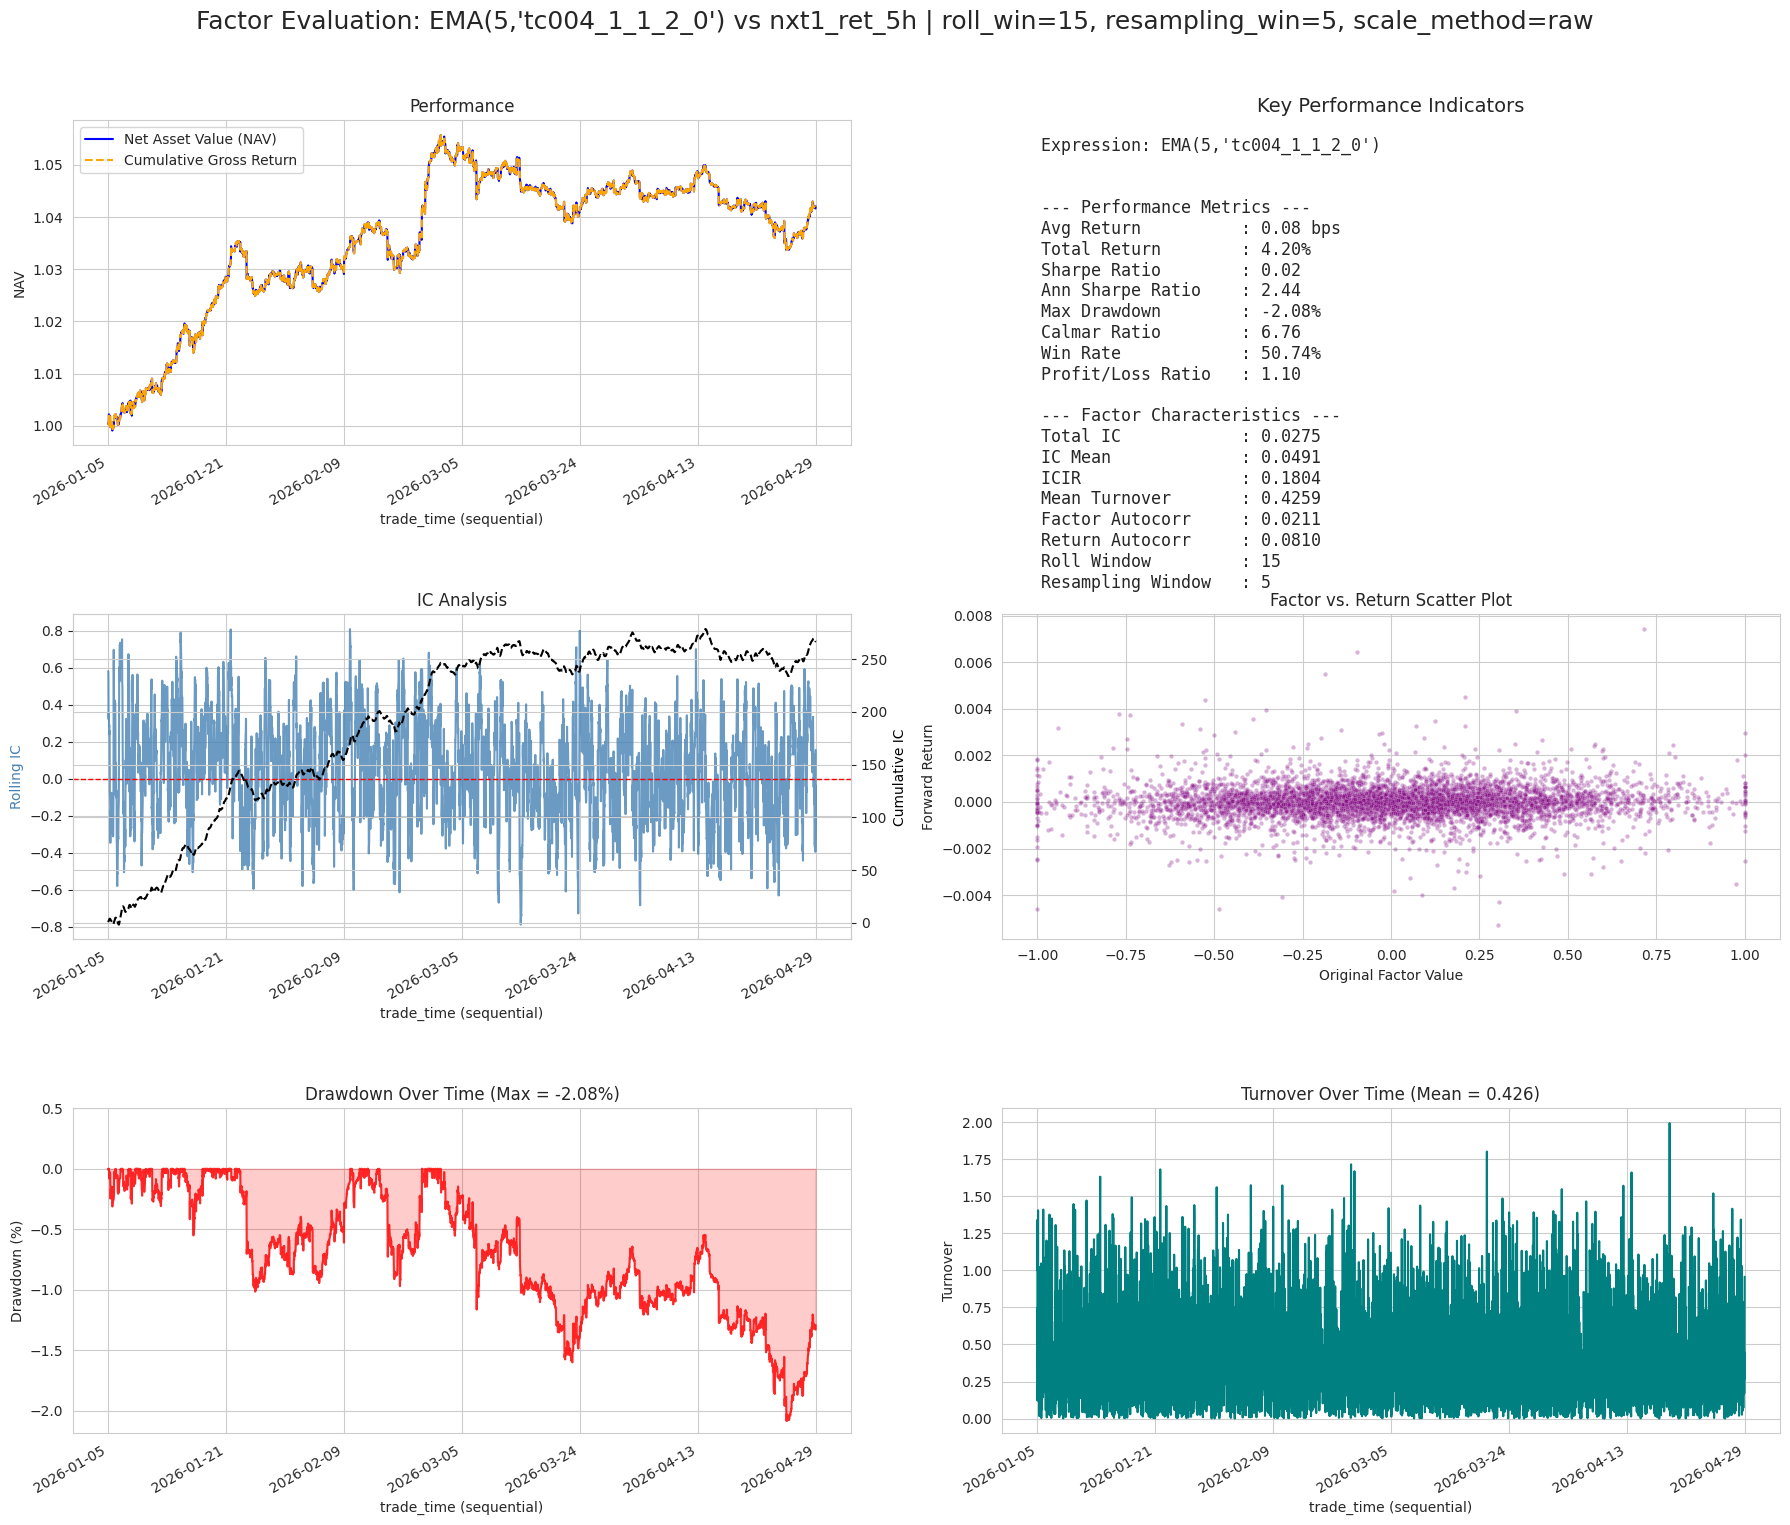

In [14]:
evaluate3 = FactorEvaluate1(factor_data=tr_data,
                                    factor_name=name,
                                    ret_name="nxt1_ret_5h",
                                    roll_win=15, ## 已经标准化过
                                    fee=0,
                                    scale_method='raw',
                                    expression=name,
                                    resampling_win=5)

evaluate3.run()
evaluate3.plot_results()